# Jz_2 Homodyne (N=2) - Scan su $\eta_-$ + Final State Tracking

Notebook per simulare omodina N=2 con:
- `phi1`, `phi2` fissati a priori
- `eta_plus = 1` fisso
- `eta_minus` variabile in una lista (estremi inclusi)

Output principali:
- curve temporali di `Concurrence` e `Spin Squeezing KU`
- **stati finali per traiettoria** (ultimo tempo)
- analisi degli stati finali tramite fidelities verso libreria di stati candidati.


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import importlib
import quantum_function2
importlib.reload(quantum_function2)

from quantum_function2 import *
from IPython.display import display, Markdown

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qutip import ket2dm, smesolve, fidelity, qsave


In [2]:
# --- SAFETY SWITCH ---
RUN_THIS_CELL = True

if not RUN_THIS_CELL:
    display(Markdown("Cell locked. Set `RUN_THIS_CELL = True` to run"))
    raise SystemExit

plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.size": 14,
    "axes.unicode_minus": False,
})


In [3]:
# DEFINITIONS (run once)
DEFAULT_EOPS = [
    ("Conc", concurrence_for_solver_general),
    ("Xi2_KU", xi_KU_solver),
]

LABELS = {
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\overline{\xi^2_{KU}}$",
}


def build_initial_state(kind: str, theta: float, phi_state: float):
    if kind == "plusplus":
        return PlusPlus
    if kind == "ee":
        return ee
    if kind == "css":
        return css_2(theta, phi_state)
    raise ValueError(f"Unknown state kind: {kind}")


def build_homodyne_ops_eta_minus(gamma: float, phi1: float, phi2: float, eta_minus: float):
    if eta_minus < 0.0 or eta_minus > 1.0:
        raise ValueError(f"eta_minus must be in [0,1], got {eta_minus}")

    L_plus = np.sqrt(gamma / 2.0) * np.exp(1j * phi1) * (Sz_1 + Sz_2)
    L_minus = np.sqrt(gamma / 2.0) * np.exp(1j * phi2) * (Sz_1 - Sz_2)

    # observed channels (homodyne current)
    sc_ops = [L_plus]
    if eta_minus > 0.0:
        sc_ops.append(np.sqrt(eta_minus) * L_minus)

    # unobserved channels (loss)
    c_ops = []
    if eta_minus < 1.0:
        c_ops.append(np.sqrt(1.0 - eta_minus) * L_minus)

    return c_ops, sc_ops


def _chunk_mean_expect(expect_chunk: np.ndarray, n_eops: int, n_times: int):
    a = np.asarray(expect_chunk)
    a = np.real_if_close(a)
    a = np.asarray(a, dtype=float)

    # Common with keep_runs_results=True: (n_eops, ntraj_chunk, n_times)
    if a.ndim == 3:
        return a.mean(axis=1)

    # Already averaged: (n_eops, n_times)
    if a.ndim == 2 and a.shape[0] == n_eops:
        return a

    # Single e_op case
    if a.ndim == 1 and n_eops == 1:
        return a.reshape(1, -1)

    # Fallback: try best-effort reshape
    return a.reshape(n_eops, n_times)


def run_homodyne_avg_eta_minus_with_finals(
    rho0,
    times: np.ndarray,
    gamma: float,
    phi1: float,
    phi2: float,
    eta_minus: float,
    e_ops: list,
    ntraj: int,
    chunk_size: int,
    num_cpus: int,
    seed: int,
):
    options = {
        "keep_runs_results": True,
        "store_states": False,
        "num_cpus": max(1, num_cpus - 1),
        "map": "parallel" if num_cpus > 1 else "serial",
    }

    weighted_sum = None
    done = 0
    chunk_id = 0
    rng = np.random.default_rng(seed)

    final_states_all = []

    n_eops = len(e_ops)
    n_times = len(times)

    while done < ntraj:
        chunk_id += 1
        n_this = min(chunk_size, ntraj - done)
        np.random.seed(int(rng.integers(0, 2**31 - 1)))

        c_ops, sc_ops = build_homodyne_ops_eta_minus(
            gamma=gamma,
            phi1=phi1,
            phi2=phi2,
            eta_minus=eta_minus,
        )

        sol = smesolve(
            H_free,
            rho0,
            times,
            c_ops=c_ops,
            sc_ops=sc_ops,
            heterodyne=False,
            e_ops=e_ops,
            ntraj=n_this,
            options=options,
        )

        mean_chunk = _chunk_mean_expect(sol.expect, n_eops=n_eops, n_times=n_times)

        if weighted_sum is None:
            weighted_sum = mean_chunk * n_this
        else:
            weighted_sum += mean_chunk * n_this

        # Keep final states for tomography/fidelity analysis.
        if hasattr(sol, "runs_final_states") and sol.runs_final_states is not None:
            final_states_all.extend(sol.runs_final_states)
        elif hasattr(sol, "runs_states") and sol.runs_states is not None:
            final_states_all.extend([traj[-1] for traj in sol.runs_states])

        done += n_this
        print(f"[eta_minus={eta_minus:.3f}] chunk {chunk_id}: {done}/{ntraj} trajectories completed")

    mean_expect = weighted_sum / float(ntraj)
    return mean_expect, final_states_all


def build_candidate_library():
    # Candidate states for "what final state is it?" analysis.
    return {
        "phi_plus": phi_plus,
        "phi_minus": phi_minus,
        "psi_plus": psi_plus,
        "psi_minus": psi_minus,
        "plusplus": PlusPlus,
        "ee": ee,
        "eg": eg,
        "ge": ge,
        "gg": gg,
    }


def fidelity_table(final_states, library: dict):
    rows = []
    labels = list(library.keys())

    for i, rho_f in enumerate(final_states, start=1):
        row = {"traj": i}
        for lab in labels:
            row[f"F_{lab}"] = float(np.real_if_close(fidelity(rho_f, library[lab])))

        best_lab = max(labels, key=lambda x: row[f"F_{x}"])
        row["best_state"] = best_lab
        row["best_fidelity"] = row[f"F_{best_lab}"]
        rows.append(row)

    return pd.DataFrame(rows)


def average_final_state(final_states):
    if len(final_states) == 0:
        return None
    rho = 0 * (final_states[0])
    for r in final_states:
        rho = rho + r
    return rho / len(final_states)


In [4]:
# PARAMETERS (modifica qui)
state_kind = "plusplus"   # "plusplus", "ee", "css"
theta = np.pi / 2          # usato solo se state_kind == "css"
phi_state = 0.0            # usato solo se state_kind == "css"

gamma = 1.0
phi1 = 0.0
phi2 = 0.0

eta_plus = 1.0
eta_minus_list = np.linspace(0.0, 1.0, 5)   # 5 estremi inclusi
eta_minus_labels = [f"{x:.2f}" for x in eta_minus_list]

ntraj = 30
chunk_size = 10
num_cpus = max(1, os.cpu_count() - 1)
seed = 12345

T1 = 1.0 / gamma
t_end = 10.0
dt = 0.01
times = np.arange(0.0, t_end * T1, dt * T1)

out_root = Path(r".\Graphs\Jz_2_Homodyne_N2_eta_minus_scan_final_state")

psi0 = build_initial_state(state_kind, theta, phi_state)
rho0 = ket2dm(psi0)

columns = [name for name, _ in DEFAULT_EOPS]
e_ops = [op for _, op in DEFAULT_EOPS]

print(f"eta_plus fixed = {eta_plus}")
print("eta_minus_list =", eta_minus_list)


eta_plus fixed = 1.0
eta_minus_list = [0.   0.25 0.5  0.75 1.  ]


In [5]:
# SIMULATION + FINAL STATE TRACKING
ineff_df = {}
final_states_dict = {}

for eta_minus, label in zip(eta_minus_list, eta_minus_labels):
    mean_expect, final_states = run_homodyne_avg_eta_minus_with_finals(
        rho0=rho0,
        times=times,
        gamma=gamma,
        phi1=float(phi1),
        phi2=float(phi2),
        eta_minus=float(eta_minus),
        e_ops=e_ops,
        ntraj=int(ntraj),
        chunk_size=int(chunk_size),
        num_cpus=int(num_cpus),
        seed=int(seed + 1000 * eta_minus),
    )

    ineff_df[label] = pd.DataFrame(mean_expect.T, columns=columns)
    final_states_dict[label] = final_states

print("Simulation completed")
for k in eta_minus_labels:
    print(f"eta_minus={k}: n_final_states = {len(final_states_dict[k])}")


10.0%. Run time:  12.80s. Est. time left: 00:00:01:55
20.0%. Run time:  12.95s. Est. time left: 00:00:00:51
30.0%. Run time:  12.96s. Est. time left: 00:00:00:30
40.0%. Run time:  12.99s. Est. time left: 00:00:00:19
50.0%. Run time:  13.07s. Est. time left: 00:00:00:13
60.0%. Run time:  13.08s. Est. time left: 00:00:00:08
70.0%. Run time:  15.07s. Est. time left: 00:00:00:06
80.0%. Run time:  15.22s. Est. time left: 00:00:00:03
90.0%. Run time:  15.23s. Est. time left: 00:00:00:01
100.0%. Run time:  15.29s. Est. time left: 00:00:00:00
Total run time:  16.10s
[eta_minus=0.000] chunk 1: 10/30 trajectories completed
10.0%. Run time:  11.73s. Est. time left: 00:00:01:45
20.0%. Run time:  11.74s. Est. time left: 00:00:00:46
30.0%. Run time:  11.78s. Est. time left: 00:00:00:27
40.0%. Run time:  11.79s. Est. time left: 00:00:00:17
50.0%. Run time:  11.84s. Est. time left: 00:00:00:11
60.0%. Run time:  11.85s. Est. time left: 00:00:00:07
70.0%. Run time:  13.88s. Est. time left: 00:00:00:05
8

In [6]:
# SAVE RESULTS (curves + final states)
phi1_dir = angle_to_path(float(phi1))
phi2_dir = angle_to_path(float(phi2))
out_dir = out_root / f"state={state_kind}_phi_1={phi1_dir}_phi_2={phi2_dir}"
out_dir.mkdir(parents=True, exist_ok=True)

meta = {
    "measurement": "homodyne",
    "N": 2,
    "state": state_kind,
    "theta": float(theta),
    "phi_state": float(phi_state),
    "gamma": float(gamma),
    "phi1": float(phi1),
    "phi2": float(phi2),
    "eta_plus_fixed": float(eta_plus),
    "eta_minus_list": [float(x) for x in eta_minus_list],
    "ntraj": int(ntraj),
    "chunk_size": int(chunk_size),
    "dt_T1": float(dt),
    "t_end_T1": float(t_end),
    "columns": columns,
}

npz_path = out_dir / f"homodyne_eta_minus_scan_phi1={float(phi1):.6g}_phi2={float(phi2):.6g}.npz"
save_ineff_df_npz(ineff_df, npz_path, meta=meta, step_col="step")
(out_dir / "run_config.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

# Save final states with qutip serializer (pickle-like)
qsave(final_states_dict, out_dir / "final_states_dict")

print(f"Saved in: {out_dir}")
print("Final states saved as: final_states_dict.qu")


Saved in: Graphs\Jz_2_Homodyne_N2_eta_minus_scan_final_state\state=plusplus_phi_1=0_phi_2=0
Final states saved as: final_states_dict.qu


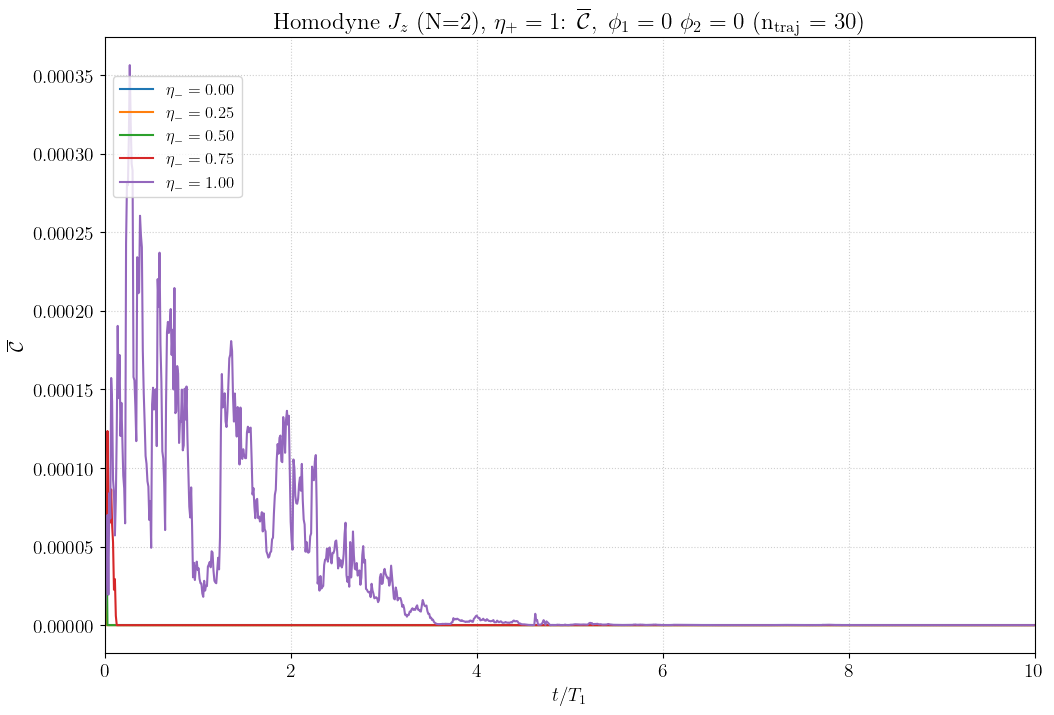

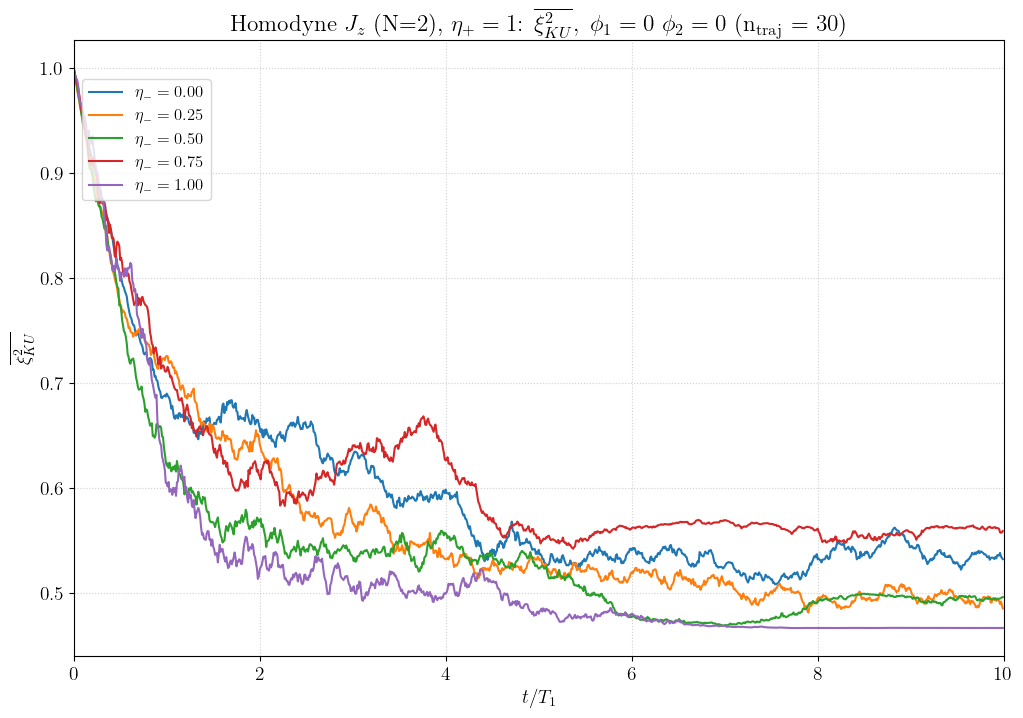

In [7]:
# PLOT + SAVE PDF
phi1_tex = angle_to_tex(float(phi1))
phi2_tex = angle_to_tex(float(phi2))

x = times / T1

for col in columns:
    plt.figure(figsize=(12, 8))

    for eta_minus, label in zip(eta_minus_list, eta_minus_labels):
        y = ineff_df[label][col].to_numpy()
        plt.plot(x, y, label=rf"$\eta_- = {eta_minus:.2f}$")

    plt.xlim(0.0, float(t_end))
    plt.xlabel(r"$t/T_1$")
    plt.ylabel(LABELS[col])
    plt.title(
        r"Homodyne $J_z$ (N=2), $\eta_+=1$: "
        + LABELS[col]
        + rf"$,\ \phi_1={phi1_tex}\ \phi_2={phi2_tex}$"
        + rf"  (n$_\mathrm{{traj}}$ = {ntraj})"
    )
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)
    plt.savefig(out_dir / f"Homodyne_eta_minus_scan_{col}.pdf", bbox_inches="tight")
    plt.show()


In [8]:
# FINAL STATE ANALYSIS VIA FIDELITIES
state_library = build_candidate_library()

fidelity_tables = {}
summary_tables = {}
avg_state_fidelities = {}

for eta_minus, label in zip(eta_minus_list, eta_minus_labels):
    ftab = fidelity_table(final_states_dict[label], state_library)
    fidelity_tables[label] = ftab

    # Summary by most likely state (argmax fidelity)
    counts = ftab.groupby("best_state").size().rename("count")
    mean_best = ftab.groupby("best_state")["best_fidelity"].mean().rename("mean_best_fidelity")
    summary = pd.concat([counts, mean_best], axis=1).sort_values("count", ascending=False)
    summary_tables[label] = summary

    # Also check fidelity of averaged final state vs library
    rho_avg = average_final_state(final_states_dict[label])
    avg_state_fidelities[label] = {
        k: float(np.real_if_close(fidelity(rho_avg, v))) for k, v in state_library.items()
    }

    print("=" * 80)
    print(f"eta_minus = {label}")
    print("Top-5 most probable final-state labels (trajectory-wise argmax fidelity):")
    print(summary.head(5))

    avg_sorted = sorted(avg_state_fidelities[label].items(), key=lambda kv: kv[1], reverse=True)
    print("Top-5 fidelities of averaged final state:")
    for k, val in avg_sorted[:5]:
        print(f"  {k:>10s}: {val:.6f}")

# Inspect one table if needed:
# fidelity_tables[eta_minus_labels[0]].head()


KeyError: 'best_state'

In [ ]:
# OPTIONAL: SAVE FIDELITY TABLES TO CSV
for label in eta_minus_labels:
    fidelity_tables[label].to_csv(out_dir / f"final_state_fidelities_eta_minus={label}.csv", index=False)
    summary_tables[label].to_csv(out_dir / f"final_state_summary_eta_minus={label}.csv")

print("Fidelity tables exported to CSV.")
